**Eurecom**
**Digital Communications**
Lab Session 3, January 2026

# Transmitter and Receiver Design for the NR Physical Random Access Channel

The purpose of our third lab exercise will deal with a particular OFDM signal used in the Uplink of 4G and 5G systems called the *Physical Random Access Channel*. It is a multiuser $M$-ary signaling strategy that is fundamental to the connectivity of a 4G/5G terminal since it is the first uplink communication with the basestations. It serves two primary purposes:

1. Transmission of a 6-bit message known as as *random-access preamble*
2. Timing offset estimation at the basestation, similar to the type of estimation done at the user-terminal (UE) using the PSS signal.

## Signal Format of the PRACH
The PRACH is an OFDM signal encoded using a so-called *Zadoff-Chu* sequence which is a type of spread-spectrum sequence. PRACH comprises a (small) number of resource-blocks (recall that this is set of 12 consecutive OFDM sub-carriers or *resource elements* in 3GPP jargon) in one or a set of consecutive slots reserved for random-access preambles. It furthermore uses a much longer cyclic prefix. The reason for a longer cyclic-prefix is to absorb the propagation delay of the channel which needs to be estimated so that the users can advance their signals. This is done as follows:
1. the basestation (gNB) receives the PRACH (also called *Msg1*), decodes the preamble (6-bits) and estimates the propagation delay.
2. in a subsequent transmission known as the *random-access response (Msg2)*, the gNB's message contains the preamble received (a sort of temporary acknowledgement) and the amount of time the terminal needs to advance its signal on subsequent uplink transmissions so that all UEs are received more or less synchronized at the gNB receiver. The latter is known as a *timing advance* and is required in OFDM systems to perform multiuser reception.
3. Reception of the first uplink message, *Msg3*, on the *Physical Uplink Shared Channel (PUSCH)* will acknowledge the proper reception of the timing advance and allow the connection procedure to proceed.

PRACH is a form of quasi-orthogonal transmission. In fact, it is a combination of *Pulse-position modulation (PPM) via a cyclic-shift* and quasi-orthogonal sequences like the PSS. There is a configurable number of positions (or shifts) of a PPM sequence. There are two extreme cases, firstly for a tiny cell (like a hotspot), 1 sequence and 64 orthogonal time-shift shifts. Secondly a huge cell, 64 quasi-orthogonal sequences without time-shifts.
In general, there is a compromise between the two, depending on the size of the cell like 4 sequences with 16-shifts each. The product should be the total number of dimensions which is 64.
The number of shifts reduces the delay that can be estimated. If the duration of the PRACH is $N$ samples, then the delay that can be "absorbed" is $N/N_{\mathrm{shifts}}$.

The PRACH signals using a common sequence remain strictly orthogonal to each other if the time-delay of the channel between UE and gNodeB plus the delay-spread of the channel is less than length of the cyclic-shift. One of the objectives of this lab session is to illustrate this behaviour. In practice, physically larger cells are configured with longer shifts so that the time-delay can be estimated properly.

The overall structure of the PRACH transmitter is shown in Figure 1. It is a regular OFDM transmitter. The frequency-domain input waveform, $X_{u,\nu}(k),k=0,1,...,L_{\mathrm{RA}}$ comprises $L_{\mathrm{RA}}$ ($N_{\mathrm{ZC}}$ in 4G) subcarriers. It depends on two parameters, $u$ which is an index in a table of so-called "roots" which allow generation of the sequence, and $\nu$ which is the cyclic time-shift index. 

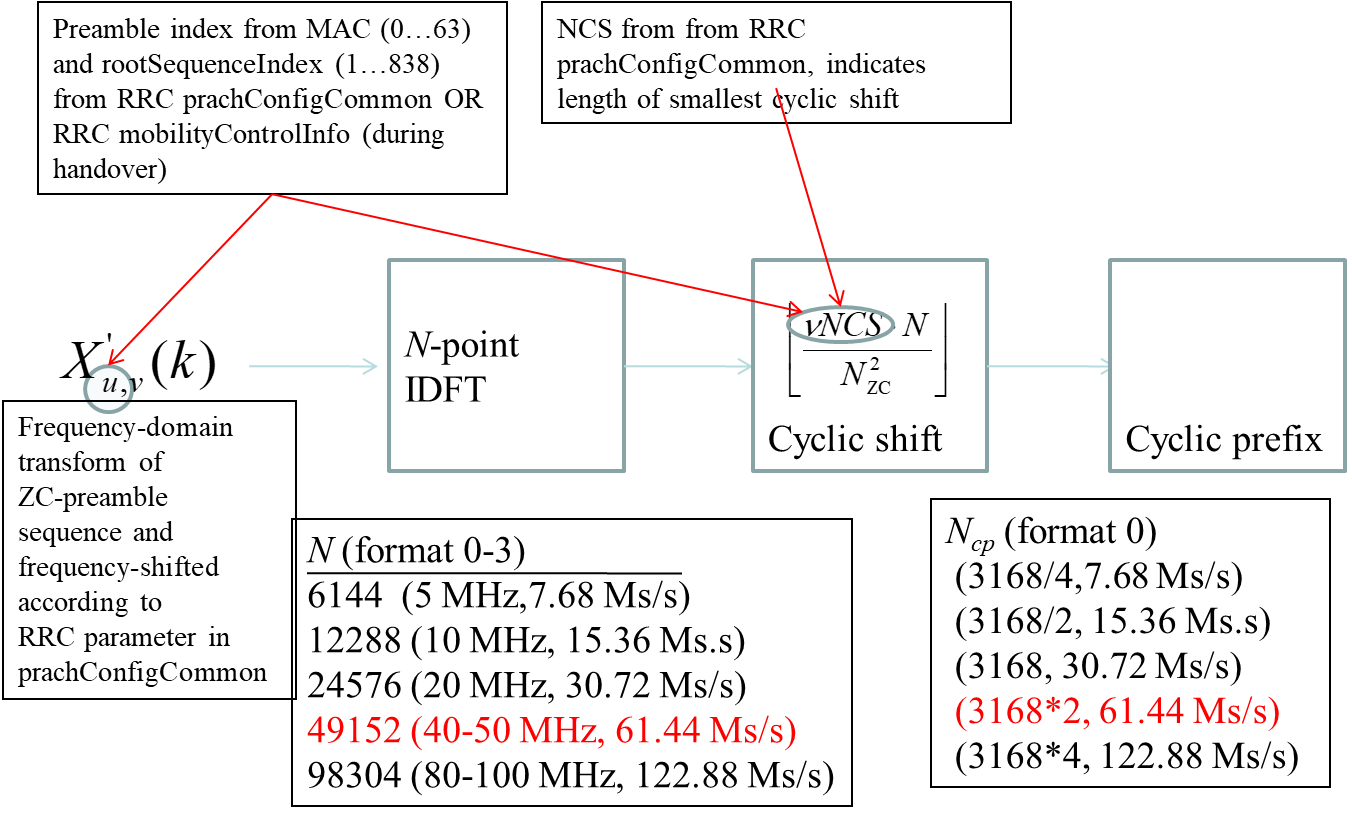
$$\text{Figure 1: Structure of the PRACH Transmitter}$$

The transmitter does the IDFT of the $X_{u,\nu}(k)$ sequence which is padded with zeros. The typical number of non-zero samples is 839 (for long format) or 139 (for short format). The format also depends on the cell size. Typical outdoor 5G networks use the length 839 PRACH which is common with the 4G system, but potentially with a different sub-carrier spacing in 5G. The size of the IDFT, $N_{\mathrm{fft}}$, depends both on the format and the bandwidth of the cell. For a 40-60 MHz cell, the normal IDFT size is 49152. You see that this is not a power of 2, in fact it is a $2^{14}\times 3$. The long-format PRACH IDFTs have a single radix-3 stage in the IDFT. The short format PRACH have a similar power of 2 and common 
IDFT/DFT size with the other downlink and uplink signals (e.g. 2048 in the cases we studied in lab sessions 1 and 2)

The Zadoff-Chu sequence is a special *root of unity* sequence defined in the time-domain as 

$$x_{u,\nu}(n) = x_{u}((n+\nu N_{cs})\mathrm{mod})L_{\mathrm{RA}},$$ 
where $x_u(n) = e^{-j\frac{\pi ui(i+1)}{L_{\mathrm{RA}}}},i=0,1,\cdots,L_{\mathrm{RA}}-1$. This signal and its time-shift are thus completely defined in the time-domain and needs to be transferred to the frequency-domain using a DFT of size $L_{\mathrm{RA}}$. In this sense it is actually an SC-FDMA or DFT-precoded OFDM signal and has good peak-to-average signal level properties. Additionally, it turns out that there is an $O(L_{\mathrm{RA}})$ algorithm for implementing this DFT which is one of the interesting algebraic properties of the Zadoff-Chu sequence. This algorithm is not necessary, however, for the purposes of this lab session but important for practical implementations of the PRACH transmitter in a UE. The parameter $N_{cs}$ is a system-level parameter which controls the length of the cyclic shifts.

The sequence $x_{u,\nu}(n)$ is thus used to generate the $X_{u,\nu}(k)$ which is placed in the frequency-domain with an offset $\overline{k}+k_1$. $\overline{k}$ is a fixed parameter depending on the frequency band of operation and $k_1$ is a parameter which depends on a system-level (MAC) configuration of the PRACH and corresponds to the first subcarrier of the PRACH occasion. This position in frequency of the PRACH, $k_1$, has a dynamic element determined in the random-access procedure (like $u,\nu$) to allow for more robust frequency-division multiplexing of the PRACH, but beyond the scope of this lab session. For the purposes of this lab session $k_1$ can be set to 0 and $\overline{k}=7$. 


**Question 1:** Implement (in Python) the OFDM symbol generation for the PRACH as a function which takes parameters, $L_{\mathrm{RA}}$, $N_{cs}$, $u$, $\nu$, $N_{\mathrm{fft}}$, $N_{\mathrm{cp}}$, $\overline{k}$, $k_1$. You can make use of the generic OFDM functions in the OFDM_xG_primer notebook to build your PRACH transmitter. 

In [1]:
# put the functions here.

For testing your function, choose $L_{\mathrm{RA}}=839$ and $N_{\mathrm{fft}}=49152$ (which corresponds to a 61.44 Msps system). The length of the cyclic prefix, $N_{\mathrm{cp}}$ is 6336. The first 6 $u$ values for the $L_{\mathrm{RA}}=839$ configuration are $u_i=[129, 710, 140, 699, 120, 719]$


**Question 2:** Determine the number of sequences and number of shifts as a function of the value $N_{cs}$. For $N_{cs}=26$ you should see that there are 2 sequences with 32 shifts (remember, the product is 64).


**Question 3:** Plot the frequency-domain signal on a dB scale (power spectrum) and compute the equivalent number of PRBs of a 30kHz uplink waveform. You should be able to do this analytically (hint: compute the sub-carrier spacing of the PRACH assuming a DFT size of 49152 and sampling frequency of 61.44 Msps, each carrier of the PRACH has a fraction of 30kHz sub-carriers. When you multiply by 839 you get the approximate bandwidth of the PRACH).


In [2]:
# put the frequency-domain plots here

**Question 4:** Plot the time-domain waveform (including the cyclic-prefix) on a 2D-plot (i.e. real vs. imaginary). You should allow the plot to join points with lines to see the transitions around the origin. This should show the limited peak-to-average power ratio. You should also try to compute it with a python function. For instance by computing:
$$10\log_{10}\left(\frac{\max_n(|x(n)|^2}{\mathrm{E} |x(n)|^2}\right)$$

In [3]:
# put the time-domain analysis here

## Building and Testing the PRACH receiver
Here we will build a channel simulation of the PRACH transmission including a propagation delay. You can reuse the TDL-A channel described in the OFDM_xG_primer notebook, along with the noise generation. Try to use a fairly high signal-to-noise ratio (like 20 dB) so you can see the signals clearly while building the receiver. You can change this later. Use the functions you created in the first section to generate 3 different PRACH waveforms, call them $x_i(n),i=0,1,2$ and give each one a different delay, $d_i,i=0,1,2$ and gain $a_i,i=0,1,2$. Apply a different TDL-A channel to each one. For each signal, use a buffer of length, say $\max_i(d_i)+N_{\mathrm{fft}}+2*N_{\mathrm{cp}}$ to include the longest delay and then lengths of the signal and channel (which should be shorter than $N_{\mathrm{cp}}$. You can then have signal like:
$$r(n) = \sum_{i=0}^{2} \sqrt{a_i}x_i(n-d_i) + z(n)$$
which can be used to test the PRACH receiver. The goal is to be able to detect the data from different $x_i(n)$ and to estimate the $d_i$.

Detecting the PRACH is a two-step procedure. First, the overall signal must be converted to the frequency-domain. This is done using the DFT with length $N_{\mathrm{fft}}$ used by the transmitter (here 49152). Call this $R(k)=\mathrm{DFT}(r(n))$. Then, for each sequence generated by $u_j$ we must implement a correlation (like the PSS) but here in the frequency-domain as 
$$R_j(k) = R(k+k_1)\odot X^{*}_{u_j,0}(k), k=0,1,\cdots,L_{\mathrm{RA}}$$
Note that we correlate with shift 0 since we are trying to detect the shift. We then compute $r_j(n) = \mathrm{IDFT}(R_j(k)$